In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import cleaning_stephanie as cs
import seaborn as sns

In [3]:
Name_Soil_Temp = "Foremost_AGDM.csv"
Name_Soil_Mois= "Foremost AGDM.csv"

#Manning AGDM

## Soil Temp

In [4]:
df_Soil_Temp_AGDM=pd.read_csv(Name_Soil_Temp)
df_Soil_Temp_AGDM.head()

,time,soil_temp_deg_C_at_5_cm_depth,soil_temp_deg_C_at_20_cm_depth,soil_temp_deg_C_at_50_cm_depth,soil_temp_deg_C_at_100_cm_depth
0,2005-05-01 00:00:00,2.5,5.6,7.0,7.4
1,2005-05-01 01:00:00,2.3,5.5,6.9,7.4
2,2005-05-01 02:00:00,2.1,5.4,7.0,7.4
3,2005-05-01 03:00:00,1.8,5.4,6.9,7.4
4,2005-05-01 04:00:00,1.6,5.3,6.9,7.4


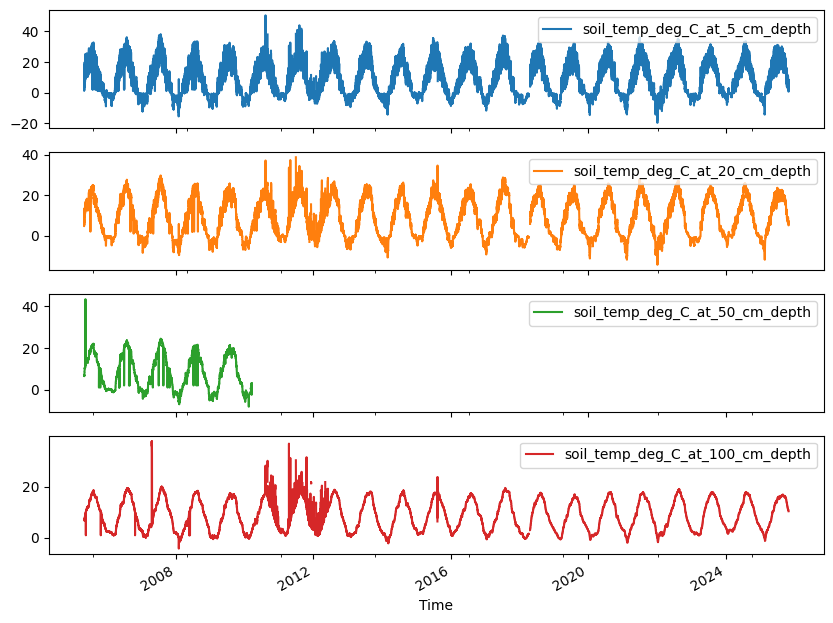

In [5]:
df_Soil_Temp_AGDM["time"] = pd.to_datetime(df_Soil_Temp_AGDM["time"])
df_Soil_Temp_AGDM = df_Soil_Temp_AGDM.set_index("time")

variables = df_Soil_Temp_AGDM.columns.values

df_Soil_Temp_AGDM[variables].plot(subplots=True, figsize=(10, 8), sharex=True)

plt.xlabel("Time")
plt.show()

In [6]:
df_Soil_Temp_AGDM.mean()

,0
soil_temp_deg_C_at_5_cm_depth,8.470428
soil_temp_deg_C_at_20_cm_depth,8.673599
soil_temp_deg_C_at_50_cm_depth,8.547843
soil_temp_deg_C_at_100_cm_depth,8.823551


In [7]:
df_Soil_Temp_AGDM.max()

,0
soil_temp_deg_C_at_5_cm_depth,50.5
soil_temp_deg_C_at_20_cm_depth,38.8
soil_temp_deg_C_at_50_cm_depth,43.5
soil_temp_deg_C_at_100_cm_depth,37.8


In [8]:
df_Soil_Temp_AGDM.min()

,0
soil_temp_deg_C_at_5_cm_depth,-19.8
soil_temp_deg_C_at_20_cm_depth,-14.4
soil_temp_deg_C_at_50_cm_depth,-8.2
soil_temp_deg_C_at_100_cm_depth,-4.2


In [9]:
NaN_Original=df_Soil_Temp_AGDM.isna().sum()
NaN_Original

,0
soil_temp_deg_C_at_5_cm_depth,3950
soil_temp_deg_C_at_20_cm_depth,3962
soil_temp_deg_C_at_50_cm_depth,137955
soil_temp_deg_C_at_100_cm_depth,4005


In [10]:
df_Soil_Temp_AGDM.notna().sum()

,0
soil_temp_deg_C_at_5_cm_depth,175777
soil_temp_deg_C_at_20_cm_depth,175765
soil_temp_deg_C_at_50_cm_depth,41772
soil_temp_deg_C_at_100_cm_depth,175722


# Specific TH Stuck
In this method we remove any set of repeated values larger than  `sens_stuck `. This method is better for the model fitting part.

##Neighborhood Outliers

This proposal eliminates an entire neighborhood of size `segment_th` surrounding any value considered an outlier. This is because, when using the returns approach, the first point might be an outlier with respect to the previous normal trend, but subsequent points will be normal with respect to the outlier. However, only the first detected outlier will be eliminated, as subsequent returns would be normal with respect to the removed outlier.

The current method looks for outliers with a positive or negative jump and searches the surroundings for an opposite jump that adjusts to the normal value without counting intermediate NaN values ​​that might be present to remove the section completely.

###Returns Removed Using Percentils
An outlier is considered to be any return that is above the `up` percentile or below the `low` percentile.


In [11]:
from cleaning_stephanie import soil_temp_percentil_neighborhood_outliers

Text(0.5, 0, 'Time')

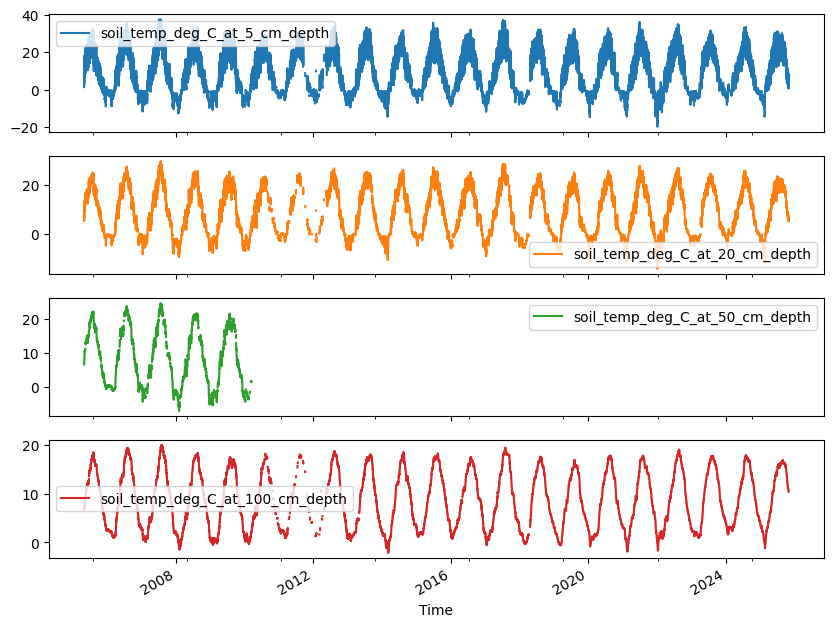

In [12]:
df_Clean_per,returns_per_clean=soil_temp_percentil_neighborhood_outliers(df=df_Soil_Temp_AGDM,low=0.00001,up=0.99999,th_returns=200,sens_stuck=50,segment_th = 20)

df_Clean_per[variables].plot(
    subplots=True,
    figsize=(10, 8),
    sharex=True
)

plt.xlabel("Time")

In [13]:
df_Clean_per.to_csv("Foremost_AGDM_temperature_cleaned.csv")

In [14]:
df_Clean_per.max()

,0
soil_temp_deg_C_at_5_cm_depth,37.6
soil_temp_deg_C_at_20_cm_depth,29.8
soil_temp_deg_C_at_50_cm_depth,24.5
soil_temp_deg_C_at_100_cm_depth,20.0


In [15]:
df_Clean_per.min()

,0
soil_temp_deg_C_at_5_cm_depth,-19.8
soil_temp_deg_C_at_20_cm_depth,-14.4
soil_temp_deg_C_at_50_cm_depth,-7.0
soil_temp_deg_C_at_100_cm_depth,-2.1


In [16]:
df_Clean_per.notna().sum()

,0
soil_temp_deg_C_at_5_cm_depth,143127
soil_temp_deg_C_at_20_cm_depth,159744
soil_temp_deg_C_at_50_cm_depth,35639
soil_temp_deg_C_at_100_cm_depth,154386


In [17]:
NaN_New=df_Clean_per.isna().sum()
NaN_New

,0
soil_temp_deg_C_at_5_cm_depth,36600
soil_temp_deg_C_at_20_cm_depth,19983
soil_temp_deg_C_at_50_cm_depth,144088
soil_temp_deg_C_at_100_cm_depth,25341


In [18]:
Anomalous=NaN_New-NaN_Original
Anomalous

,0
soil_temp_deg_C_at_5_cm_depth,32650
soil_temp_deg_C_at_20_cm_depth,16021
soil_temp_deg_C_at_50_cm_depth,6133
soil_temp_deg_C_at_100_cm_depth,21336


In [19]:
df_Clean_per

,soil_temp_deg_C_at_5_cm_depth,soil_temp_deg_C_at_20_cm_depth,soil_temp_deg_C_at_50_cm_depth,soil_temp_deg_C_at_100_cm_depth
time,,,,
2005-05-01 00:00:00,NaN,NaN,NaN,NaN
2005-05-01 01:00:00,NaN,NaN,NaN,NaN
2005-05-01 02:00:00,NaN,NaN,NaN,NaN
2005-05-01 03:00:00,NaN,NaN,NaN,NaN
2005-05-01 04:00:00,NaN,NaN,NaN,NaN
...,...,...,...,...
2025-10-31 19:00:00,5.1,5.7,NaN,10.5
2025-10-31 20:00:00,5.0,5.8,NaN,10.5
2025-10-31 21:00:00,5.0,5.8,NaN,10.5


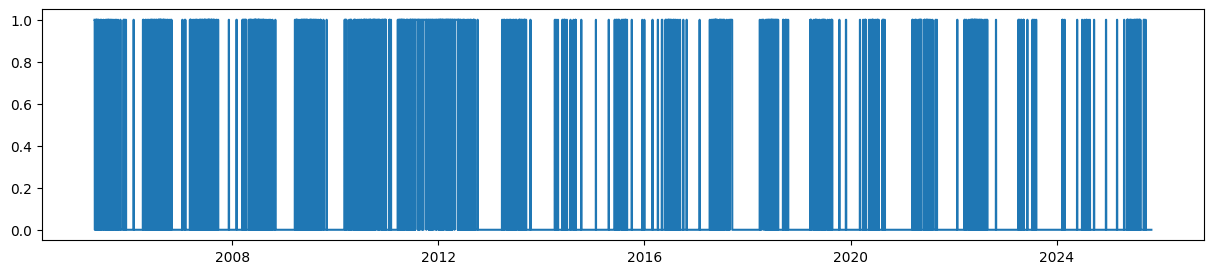

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,3))
plt.plot(df_Clean_per['soil_temp_deg_C_at_5_cm_depth'].isna())
plt.show()

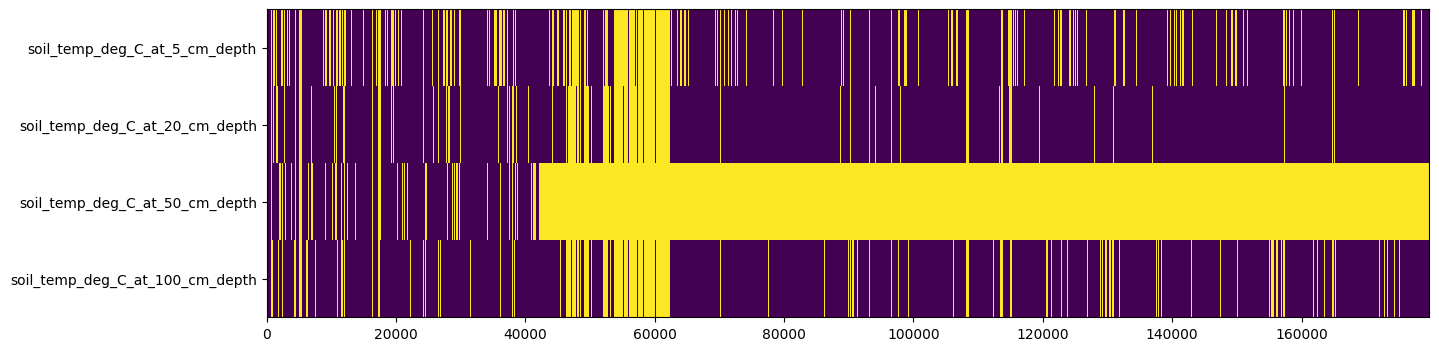

In [21]:
plt.figure(figsize=(15,4))
plt.imshow(
    df_Clean_per.isna().T,
    aspect='auto',
    interpolation='nearest'
)
plt.yticks(range(len(df_Clean_per.columns)), df_Clean_per.columns)
plt.show()

In [22]:
df_Clean_per.shape


(179727, 4)

In [23]:
df_Clean_per.isna().sum()

,0
soil_temp_deg_C_at_5_cm_depth,36600
soil_temp_deg_C_at_20_cm_depth,19983
soil_temp_deg_C_at_50_cm_depth,144088
soil_temp_deg_C_at_100_cm_depth,25341


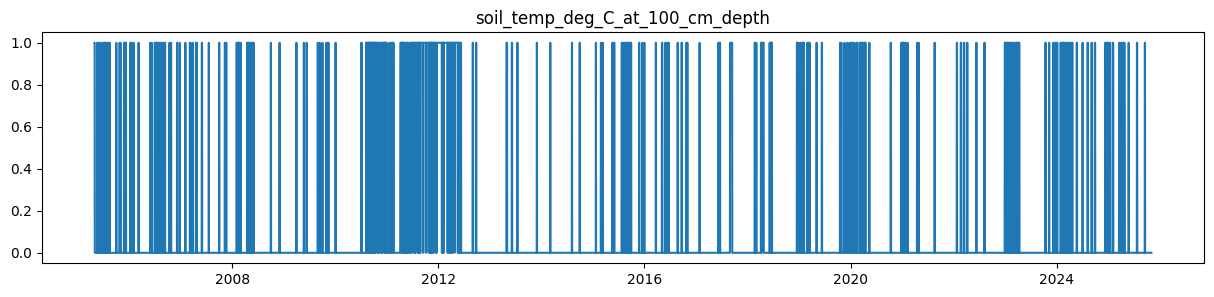

In [24]:
col = 'soil_temp_deg_C_at_100_cm_depth'

plt.figure(figsize=(15,3))
plt.plot(df_Clean_per[col].isna().astype(int))
plt.title(col)
plt.show()

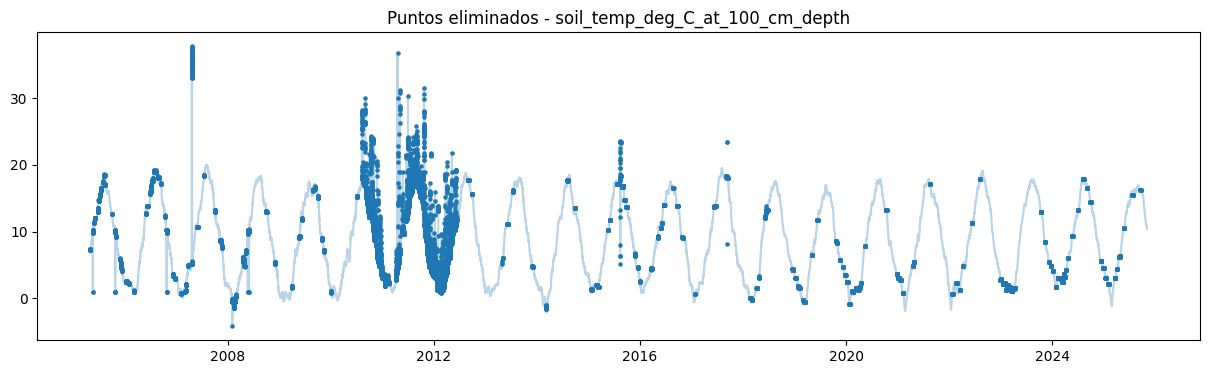

In [25]:
col = 'soil_temp_deg_C_at_100_cm_depth'

# puntos que fueron eliminados en el limpio
bad_mask = df_Clean_per[col].isna()

plt.figure(figsize=(15,4))

# serie original completa
plt.plot(df_Soil_Temp_AGDM.index,
         df_Soil_Temp_AGDM[col],
         alpha=0.3)

# puntos eliminados resaltados
plt.scatter(df_Soil_Temp_AGDM.index[bad_mask],
            df_Soil_Temp_AGDM.loc[bad_mask, col],
            s=5)

plt.title(f'Puntos eliminados - {col}')
plt.show()

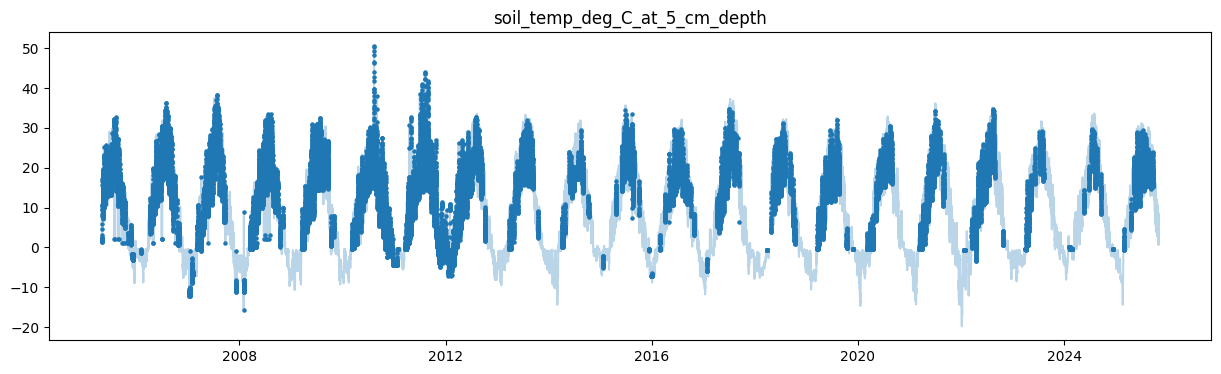

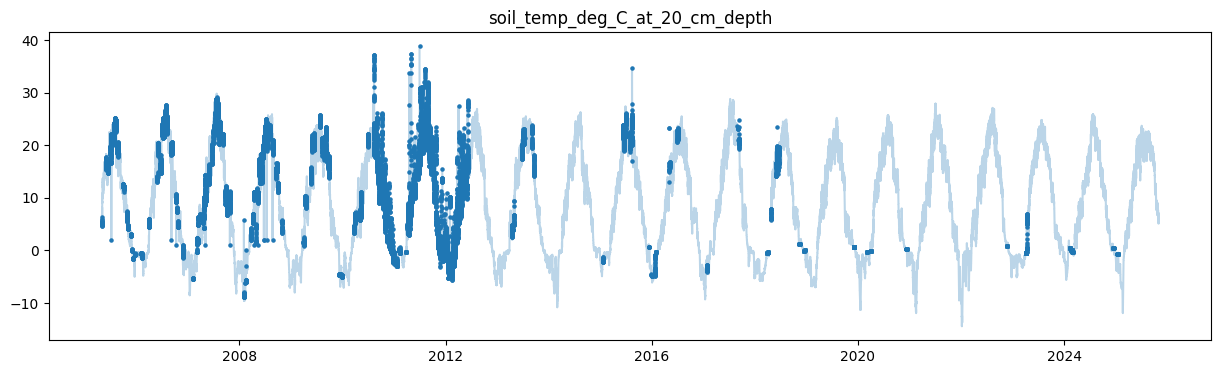

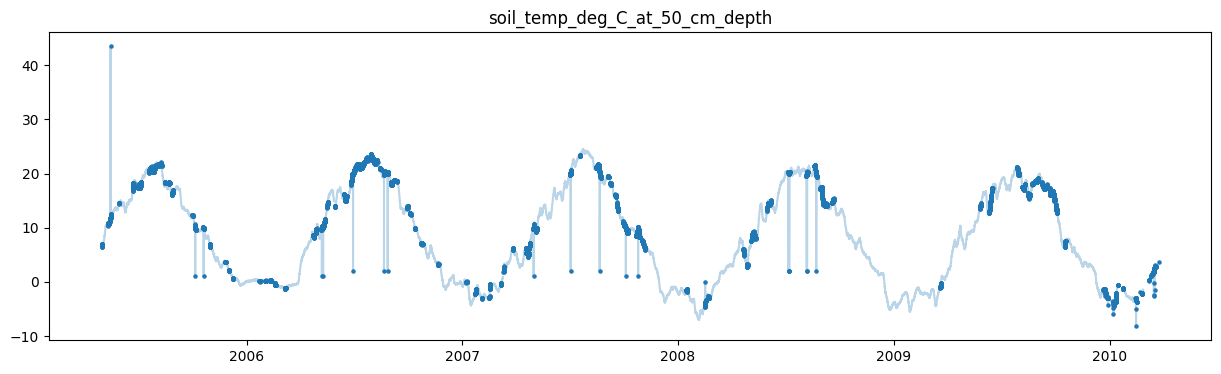

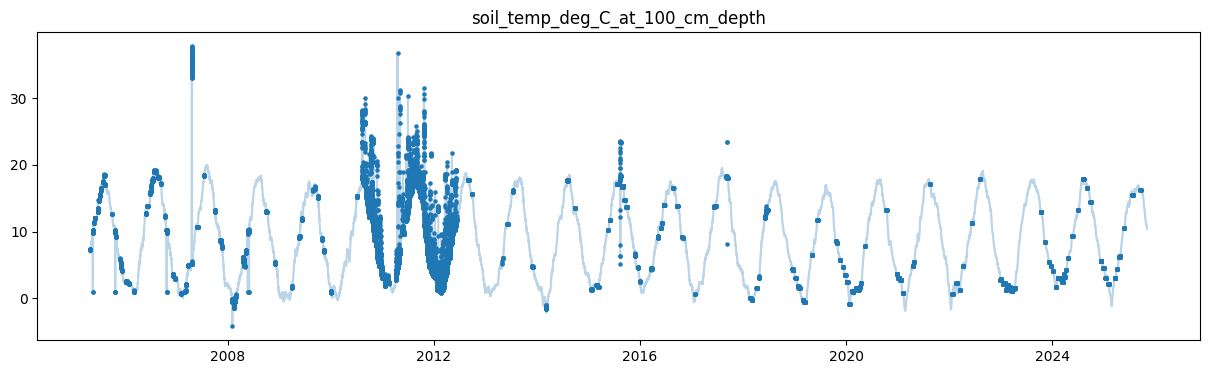

In [26]:
for col in df_Soil_Temp_AGDM.columns:

    bad_mask = (
    df_Clean_per[col].isna()
    & df_Soil_Temp_AGDM[col].notna()
    )

    plt.figure(figsize=(15,4))

    plt.plot(df_Soil_Temp_AGDM.index,
             df_Soil_Temp_AGDM[col],
             alpha=0.3)

    plt.scatter(df_Soil_Temp_AGDM.index[bad_mask],
                df_Soil_Temp_AGDM.loc[bad_mask, col],
                s=5)

    plt.title(col)
    plt.show()

In [27]:
df_Clean_per.isna().sum()

,0
soil_temp_deg_C_at_5_cm_depth,36600
soil_temp_deg_C_at_20_cm_depth,19983
soil_temp_deg_C_at_50_cm_depth,144088
soil_temp_deg_C_at_100_cm_depth,25341


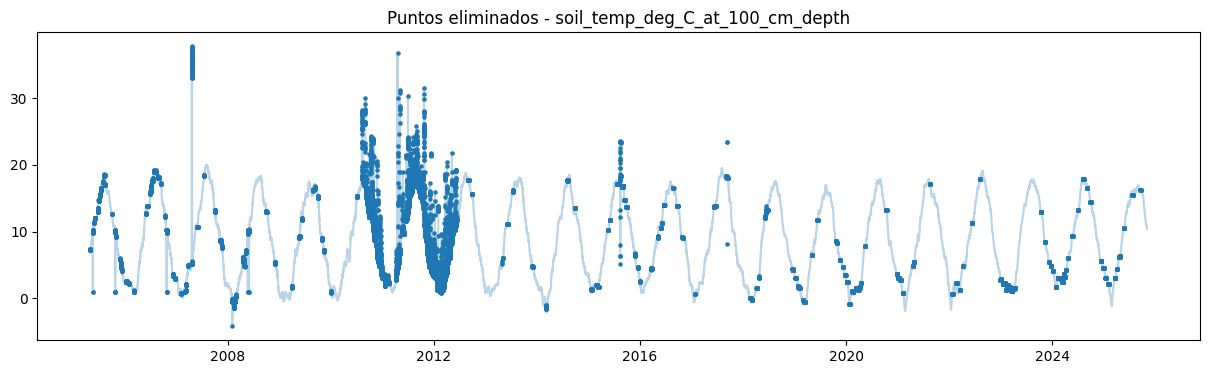

In [28]:
col = 'soil_temp_deg_C_at_100_cm_depth'

# puntos que fueron eliminados en el limpio
bad_mask = df_Clean_per[col].isna()

plt.figure(figsize=(15,4))

# serie original completa
plt.plot(df_Soil_Temp_AGDM.index,
         df_Soil_Temp_AGDM[col],
         alpha=0.3)

# puntos eliminados resaltados
plt.scatter(df_Soil_Temp_AGDM.index[bad_mask],
            df_Soil_Temp_AGDM.loc[bad_mask, col],
            s=5)

plt.title(f'Puntos eliminados - {col}')
plt.show()

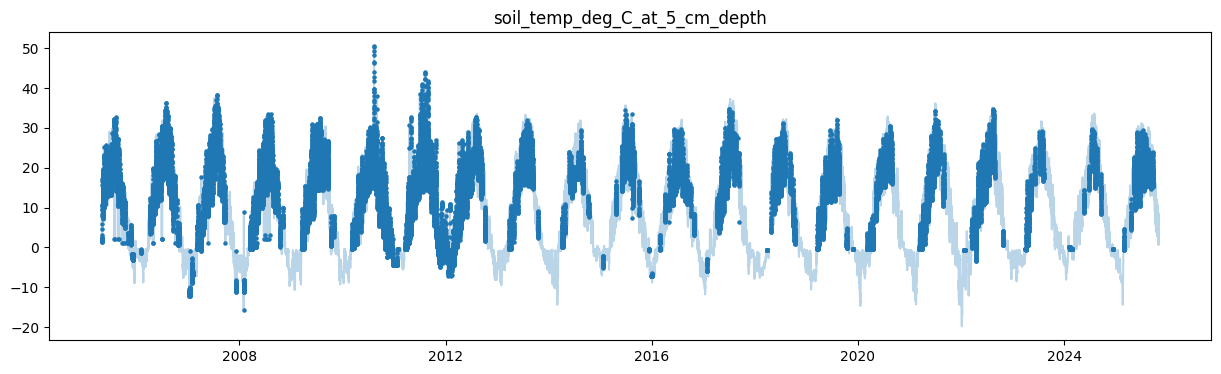

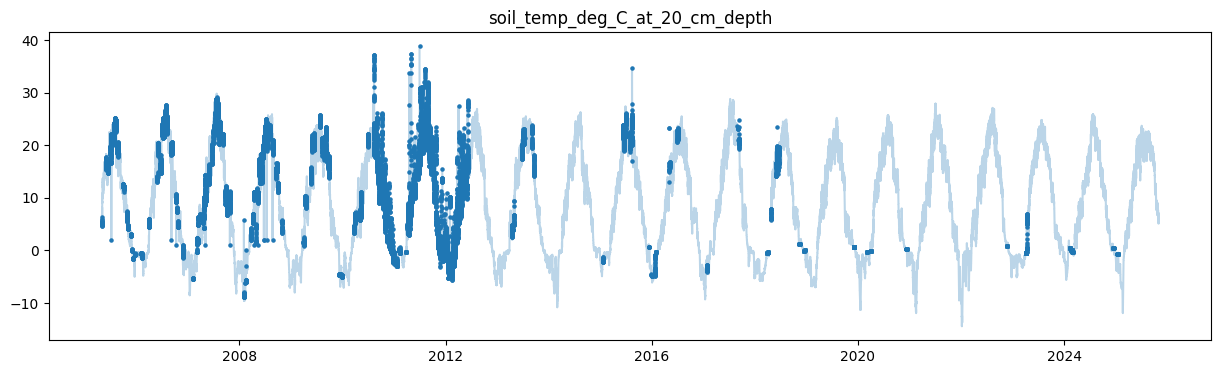

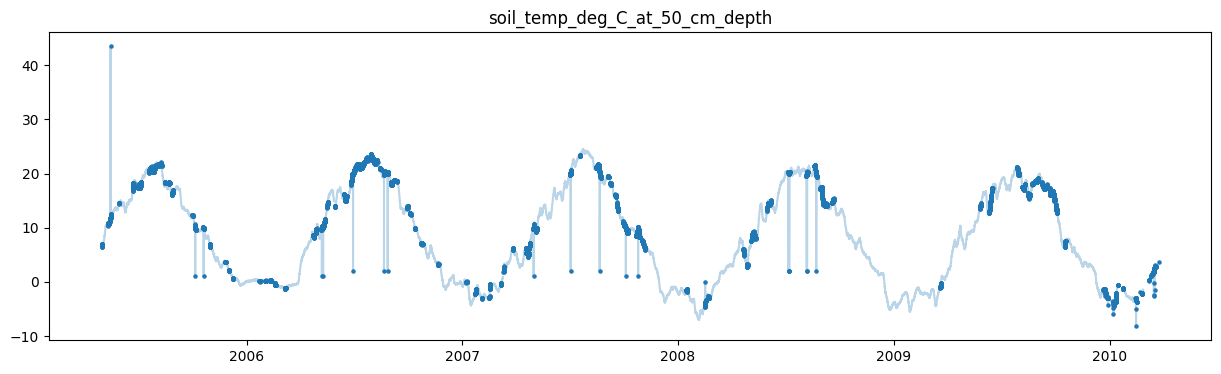

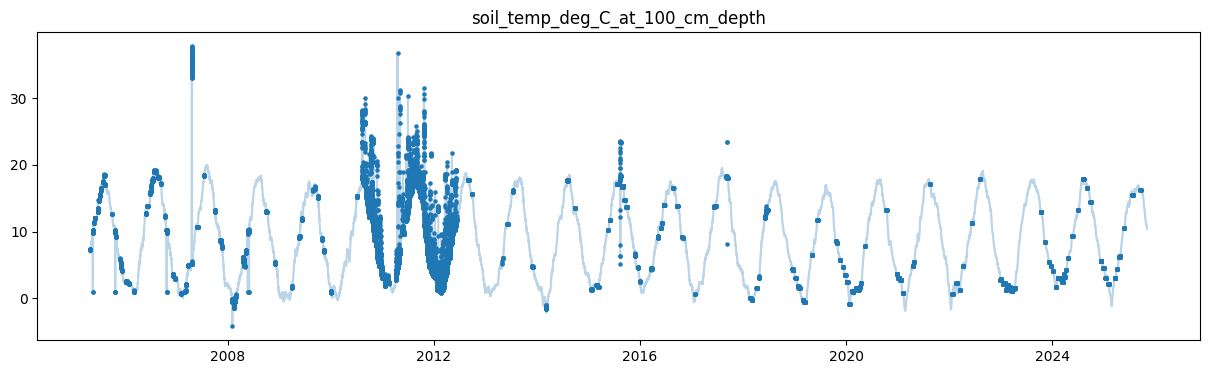

In [29]:
for col in df_Soil_Temp_AGDM.columns:

    bad_mask = (
    df_Clean_per[col].isna()
    & df_Soil_Temp_AGDM[col].notna()
    )

    plt.figure(figsize=(15,4))

    plt.plot(df_Soil_Temp_AGDM.index,
             df_Soil_Temp_AGDM[col],
             alpha=0.3)

    plt.scatter(df_Soil_Temp_AGDM.index[bad_mask],
                df_Soil_Temp_AGDM.loc[bad_mask, col],
                s=5)

    plt.title(col)
    plt.show()

# Z Scores Not Used


In [30]:
from cleaning_stephanie import soil_temp_zscores_neighborhood_outliers

Text(0.5, 0, 'Time')

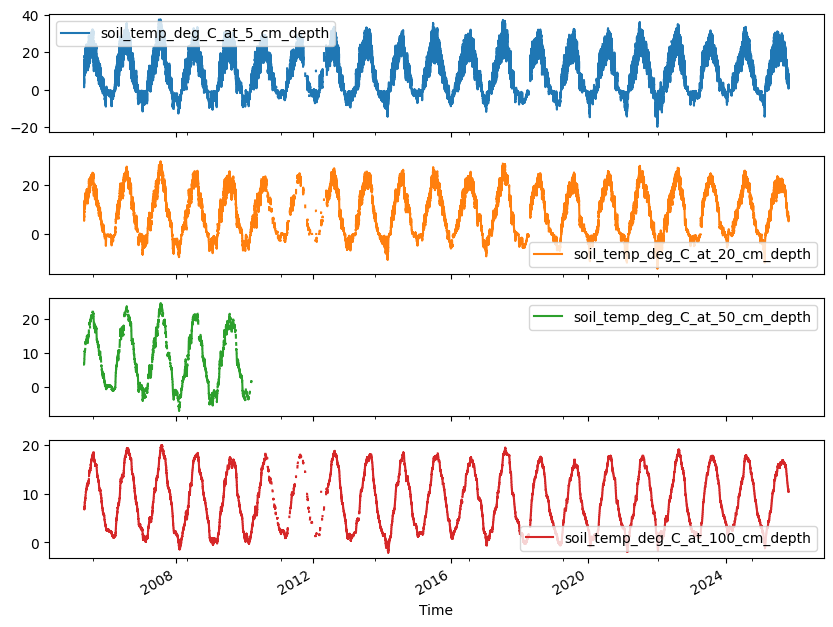

In [31]:
df_Clean_per,returns_per_clean=soil_temp_zscores_neighborhood_outliers(df=df_Soil_Temp_AGDM,zscr_sd=3,th_returns=2,sens_stuck=20,segment_th = 20)

df_Clean_per[variables].plot(
    subplots=True,
    figsize=(10, 8),
    sharex=True
)

plt.xlabel("Time")


In [32]:
df_Clean_per.max()

,0
soil_temp_deg_C_at_5_cm_depth,37.6
soil_temp_deg_C_at_20_cm_depth,29.8
soil_temp_deg_C_at_50_cm_depth,24.5
soil_temp_deg_C_at_100_cm_depth,20.0


In [33]:
df_Clean_per.min()

,0
soil_temp_deg_C_at_5_cm_depth,-19.8
soil_temp_deg_C_at_20_cm_depth,-14.4
soil_temp_deg_C_at_50_cm_depth,-7.0
soil_temp_deg_C_at_100_cm_depth,-2.1


In [34]:
df_Clean_per.notna().sum()

,0
soil_temp_deg_C_at_5_cm_depth,136720
soil_temp_deg_C_at_20_cm_depth,143539
soil_temp_deg_C_at_50_cm_depth,32562
soil_temp_deg_C_at_100_cm_depth,127805


In [35]:
NaN_New=df_Clean_per.isna().sum()
NaN_New

,0
soil_temp_deg_C_at_5_cm_depth,43007
soil_temp_deg_C_at_20_cm_depth,36188
soil_temp_deg_C_at_50_cm_depth,147165
soil_temp_deg_C_at_100_cm_depth,51922


In [36]:
Anomalous=NaN_New-NaN_Original
Anomalous

,0
soil_temp_deg_C_at_5_cm_depth,39057
soil_temp_deg_C_at_20_cm_depth,32226
soil_temp_deg_C_at_50_cm_depth,9210
soil_temp_deg_C_at_100_cm_depth,47917


# Moisture

In [37]:
df_Soil_Temp_AGDM=pd.read_csv(Name_Soil_Mois)
df_Soil_Temp_AGDM.head()

,time,soil_moisture_percent_at_5_cm_depth,soil_moisture_percent_at_20_cm_depth,soil_moisture_percent_at_50_cm_depth,soil_moisture_percent_at_100_cm_depth
0,2005-05-01 00:00:00,22.2,28.0,25.1,26.0
1,2005-05-01 01:00:00,22.2,28.0,25.1,26.0
2,2005-05-01 02:00:00,22.2,28.0,25.1,26.0
3,2005-05-01 03:00:00,22.1,28.0,25.1,26.0
4,2005-05-01 04:00:00,22.1,28.0,25.1,26.0


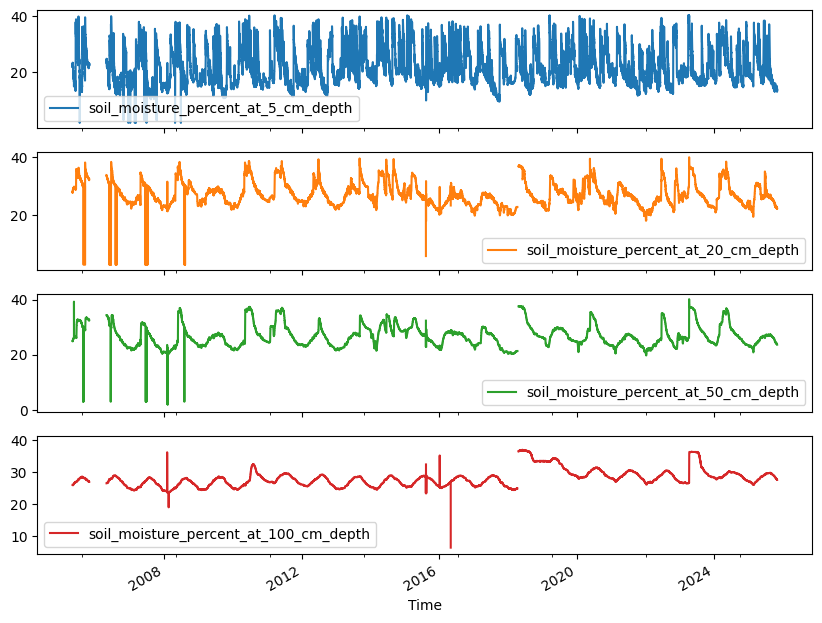

In [38]:
df_Soil_Temp_AGDM["time"] = pd.to_datetime(df_Soil_Temp_AGDM["time"])
df_Soil_Temp_AGDM = df_Soil_Temp_AGDM.set_index("time")

variables = df_Soil_Temp_AGDM.columns.values

df_Soil_Temp_AGDM[variables].plot(subplots=True, figsize=(10, 8), sharex=True)

plt.xlabel("Time")
plt.show()

In [39]:
df_Soil_Temp_AGDM.mean()

,0
soil_moisture_percent_at_5_cm_depth,22.143321
soil_moisture_percent_at_20_cm_depth,27.358033
soil_moisture_percent_at_50_cm_depth,26.893247
soil_moisture_percent_at_100_cm_depth,28.075219


In [40]:
df_Soil_Temp_AGDM.max()

,0
soil_moisture_percent_at_5_cm_depth,40.4
soil_moisture_percent_at_20_cm_depth,40.0
soil_moisture_percent_at_50_cm_depth,40.2
soil_moisture_percent_at_100_cm_depth,39.7


In [41]:
df_Soil_Temp_AGDM.min()

,0
soil_moisture_percent_at_5_cm_depth,2.0
soil_moisture_percent_at_20_cm_depth,3.0
soil_moisture_percent_at_50_cm_depth,1.2
soil_moisture_percent_at_100_cm_depth,6.1


In [42]:
NaN_Original=df_Soil_Temp_AGDM.isna().sum()
NaN_Original

,0
soil_moisture_percent_at_5_cm_depth,5761
soil_moisture_percent_at_20_cm_depth,5742
soil_moisture_percent_at_50_cm_depth,5761
soil_moisture_percent_at_100_cm_depth,5854


In [43]:
df_Soil_Temp_AGDM.notna().sum()

,0
soil_moisture_percent_at_5_cm_depth,173966
soil_moisture_percent_at_20_cm_depth,173985
soil_moisture_percent_at_50_cm_depth,173966
soil_moisture_percent_at_100_cm_depth,173873


###Returns Removed Using Percentils
An outlier is considered to be any return that is above the `up` percentile or below the `low` percentile.

Text(0.5, 0, 'Time')

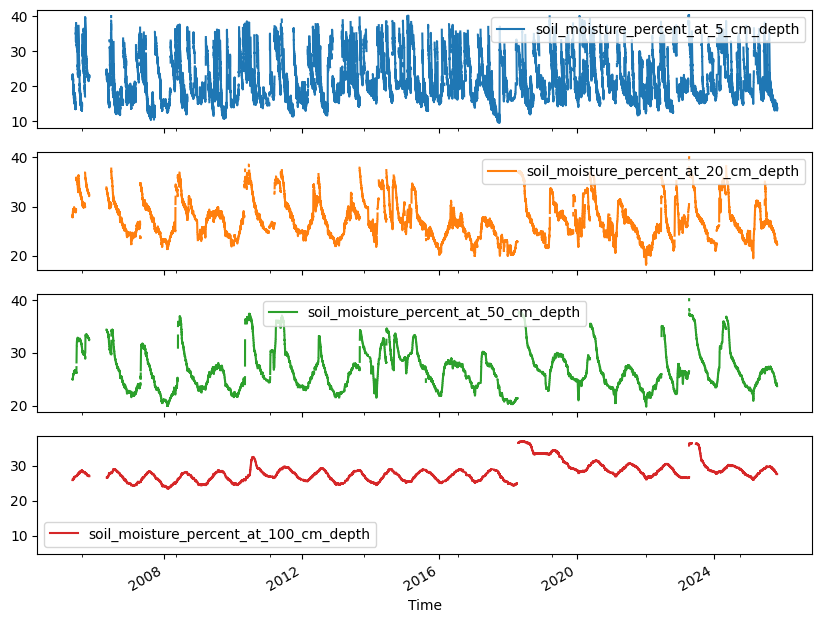

In [44]:
df_Clean_per,returns_per_clean=soil_temp_percentil_neighborhood_outliers(df=df_Soil_Temp_AGDM,low=0.00001,up=0.99999,th_returns=200,sens_stuck=50,segment_th = 2)

df_Clean_per[variables].plot(
    subplots=True,
    figsize=(10, 8),
    sharex=True
)

plt.xlabel("Time")


In [45]:
df_Clean_per.max()

,0
soil_moisture_percent_at_5_cm_depth,40.3
soil_moisture_percent_at_20_cm_depth,40.0
soil_moisture_percent_at_50_cm_depth,40.2
soil_moisture_percent_at_100_cm_depth,37.0


In [46]:
df_Clean_per.min()

,0
soil_moisture_percent_at_5_cm_depth,9.6
soil_moisture_percent_at_20_cm_depth,18.2
soil_moisture_percent_at_50_cm_depth,19.8
soil_moisture_percent_at_100_cm_depth,6.4


In [47]:
df_Clean_per.notna().sum()

,0
soil_moisture_percent_at_5_cm_depth,169078
soil_moisture_percent_at_20_cm_depth,160632
soil_moisture_percent_at_50_cm_depth,123316
soil_moisture_percent_at_100_cm_depth,50693


In [48]:
NaN_New=df_Clean_per.isna().sum()
NaN_New

,0
soil_moisture_percent_at_5_cm_depth,10649
soil_moisture_percent_at_20_cm_depth,19095
soil_moisture_percent_at_50_cm_depth,56411
soil_moisture_percent_at_100_cm_depth,129034


In [49]:
Anomalous=NaN_New-NaN_Original
Anomalous

,0
soil_moisture_percent_at_5_cm_depth,4888
soil_moisture_percent_at_20_cm_depth,13353
soil_moisture_percent_at_50_cm_depth,50650
soil_moisture_percent_at_100_cm_depth,123180


# Z Scores Not Used


In [50]:
from cleaning_stephanie import soil_temp_zscores_neighborhood_outliers

Text(0.5, 0, 'Time')

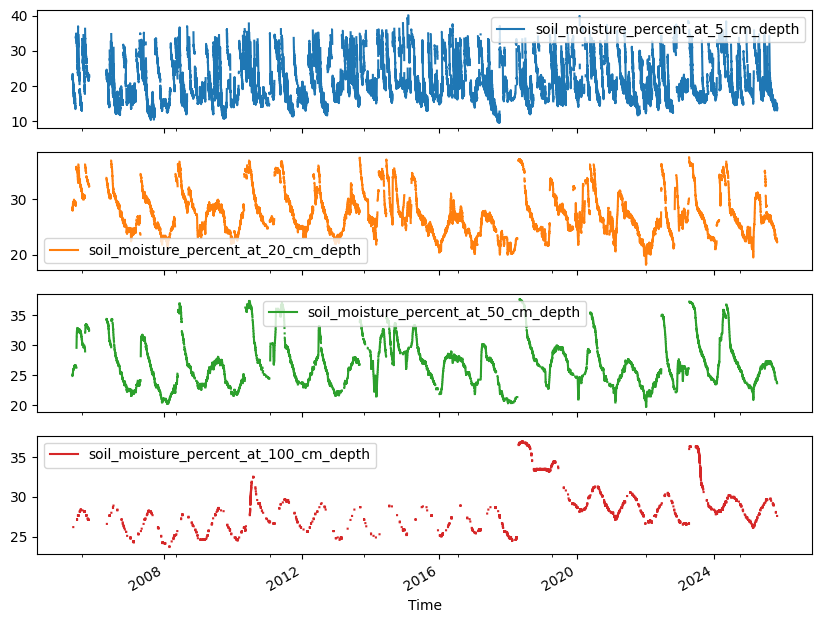

In [51]:
df_Clean_per,returns_per_clean=soil_temp_zscores_neighborhood_outliers(df=df_Soil_Temp_AGDM,zscr_sd=3,th_returns=2,sens_stuck=20,segment_th = 20)

df_Clean_per[variables].plot(
    subplots=True,
    figsize=(10, 8),
    sharex=True
)

plt.xlabel("Time")


In [52]:
df_Clean_per.max()

,0
soil_moisture_percent_at_5_cm_depth,40.1
soil_moisture_percent_at_20_cm_depth,37.5
soil_moisture_percent_at_50_cm_depth,37.7
soil_moisture_percent_at_100_cm_depth,37.0


In [53]:
df_Clean_per.min()

,0
soil_moisture_percent_at_5_cm_depth,9.6
soil_moisture_percent_at_20_cm_depth,18.2
soil_moisture_percent_at_50_cm_depth,19.8
soil_moisture_percent_at_100_cm_depth,23.5


In [54]:
df_Clean_per.notna().sum()

,0
soil_moisture_percent_at_5_cm_depth,150392
soil_moisture_percent_at_20_cm_depth,125300
soil_moisture_percent_at_50_cm_depth,55653
soil_moisture_percent_at_100_cm_depth,12961


In [55]:
NaN_New=df_Clean_per.isna().sum()
NaN_New

,0
soil_moisture_percent_at_5_cm_depth,29335
soil_moisture_percent_at_20_cm_depth,54427
soil_moisture_percent_at_50_cm_depth,124074
soil_moisture_percent_at_100_cm_depth,166766


In [56]:
Anomalous=NaN_New-NaN_Original
Anomalous

,0
soil_moisture_percent_at_5_cm_depth,23574
soil_moisture_percent_at_20_cm_depth,48685
soil_moisture_percent_at_50_cm_depth,118313
soil_moisture_percent_at_100_cm_depth,160912
